In [135]:
from nilearn import datasets, plotting
import nibabel as nib
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from nilearn.datasets import fetch_atlas_schaefer_2018
from upsetplot import UpSet, from_indicators
from nilearn.image import load_img
from venn import venn
from matplotlib.colors import LinearSegmentedColormap

These next few cells are to visualize the atlas, they're not needed for the whole notebook.

In [2]:
atlas_path = "Schaefer2018_200Parcels_7Networks_order_FSLMNI152_1mm.nii.gz"

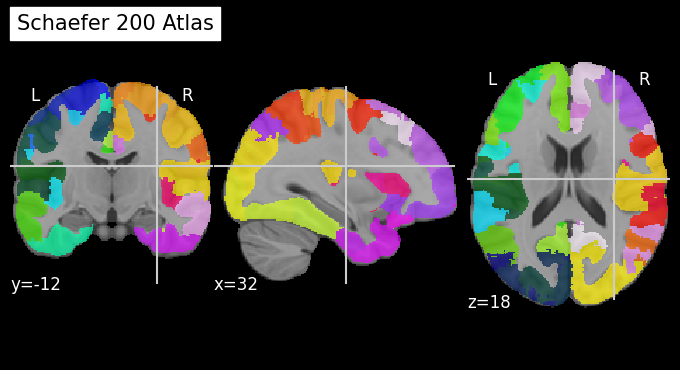

In [3]:
# Load Schaefer atlas in MNI152 space
mni152 = datasets.load_mni152_template()
plotting.plot_roi(atlas_path, bg_img=mni152, title="Schaefer 200 Atlas")
plotting.show()

Load the data

In [4]:
connectome_data = pd.read_csv("../../Dataset/widsdatathon2025/TRAIN/TRAIN_FUNCTIONAL_CONNECTOME_MATRICES.csv")

In [5]:
train_labels = pd.read_excel("../../Dataset/widsdatathon2025/TRAIN/TRAINING_SOLUTIONS.xlsx")

In [6]:
# split the data into 4 splits
train_labels_adhd_male = train_labels[(train_labels["ADHD_Outcome"] == 1) & (train_labels["Sex_F"] == 0)] 
train_labels_adhd_female = train_labels[(train_labels["ADHD_Outcome"] == 1) & (train_labels["Sex_F"] == 1)] 
train_labels_no_adhd_male = train_labels[(train_labels["ADHD_Outcome"] == 0) & (train_labels["Sex_F"] == 0)] 
train_labels_no_adhd_female = train_labels[(train_labels["ADHD_Outcome"] == 0) & (train_labels["Sex_F"] == 1)] 

In [7]:
connectome_data_adhd_male = connectome_data[connectome_data['participant_id'].isin(train_labels_adhd_male['participant_id'])]
connectome_data_adhd_female = connectome_data[connectome_data['participant_id'].isin(train_labels_adhd_female['participant_id'])]
connectome_data_no_adhd_male = connectome_data[connectome_data['participant_id'].isin(train_labels_no_adhd_male['participant_id'])]
connectome_data_no_adhd_female = connectome_data[connectome_data['participant_id'].isin(train_labels_no_adhd_female['participant_id'])]

In [8]:
expected_num_regions = 200

Build Adjacency matrices for 4 classes - ADHD (male), ADHD (female), No ADHD (male), No ADHD (female)

In [9]:
def construct_adjacency_matrix(connectome_data):
    connectivity_vectors = connectome_data.iloc[:, 1:].values
    num_patients = connectome_data.shape[0]

    upper_tri_indices = np.triu_indices(expected_num_regions, k=1)

    matrix_full = np.zeros((num_patients, expected_num_regions, expected_num_regions))

    for i in range(num_patients):
        matrix = np.zeros((expected_num_regions, expected_num_regions))
        matrix[upper_tri_indices] = connectivity_vectors[i]  
        matrix += matrix.T 
        np.fill_diagonal(matrix, 0)  
        matrix_full[i] = matrix

    return matrix_full  

In [10]:
matrix_adhd_male = construct_adjacency_matrix(connectome_data_adhd_male)
matrix_adhd_female = construct_adjacency_matrix(connectome_data_adhd_female)
matrix_no_adhd_male = construct_adjacency_matrix(connectome_data_no_adhd_male)
matrix_no_adhd_female = construct_adjacency_matrix(connectome_data_no_adhd_female)

In [11]:
print(matrix_adhd_male.shape)
print(matrix_adhd_female.shape)
print(matrix_no_adhd_male.shape)
print(matrix_no_adhd_female.shape)

(581, 200, 200)
(250, 200, 200)
(216, 200, 200)
(166, 200, 200)


<Axes: >

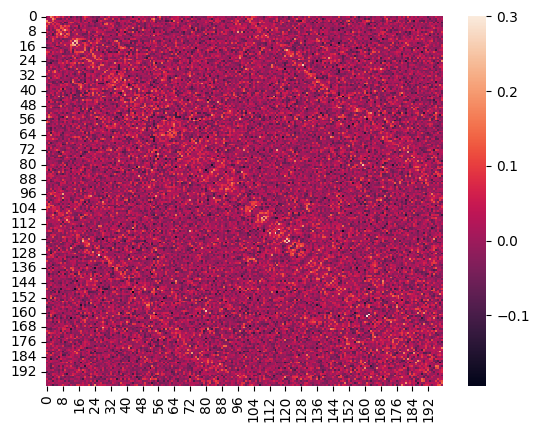

In [12]:
sns.heatmap(matrix_adhd_female[0])

In [13]:
mean_matrix_adhd_female = np.mean(matrix_adhd_female, axis=0)
mean_matrix_adhd_male = np.mean(matrix_adhd_male, axis=0)
mean_matrix_no_adhd_female = np.mean(matrix_no_adhd_female, axis=0)
mean_matrix_no_adhd_male = np.mean(matrix_no_adhd_male, axis=0)

In [14]:
mean_matrix_adhd_female.shape

(200, 200)

<Axes: >

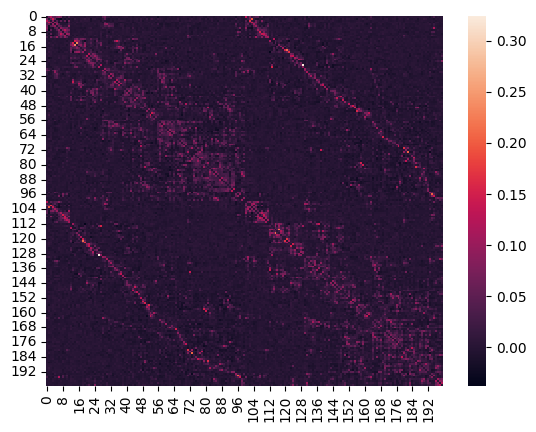

In [15]:
sns.heatmap(mean_matrix_adhd_female)

Plot the connectome based on "schaefer_2018" atlas with 200 regions, 7 netoworks and 1mm resolution. (This is the closest assumption I could get to). 10 nodes are plotted for visualization.

[get_dataset_dir] Dataset found in /Users/saadbinashraf/nilearn_data/schaefer_2018


/Users/saadbinashraf/Drive/Work/WiDS /Code/Scripts/venv/lib/python3.12/site-packages/nilearn/plotting/img_plotting.py:1746: UserWarning: The given float value must not exceed 0.14205231343261324. But, you have given threshold=0.2.
  display.add_graph(


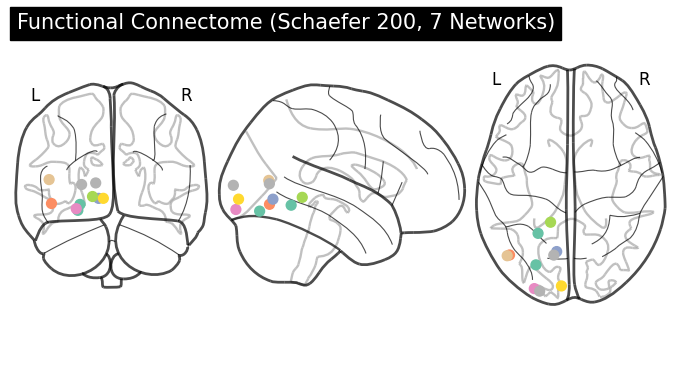

In [138]:
# Load Schaefer 2018 Atlas (200 parcels, 7 networks, 1mm MNI152)
atlas = fetch_atlas_schaefer_2018(n_rois=200, yeo_networks=7, resolution_mm=1)

# Extract MNI152 coordinates for 200 regions
atlas_img = load_img(atlas.maps)  # Load the atlas image

# Use nilearn's built-in function to find centroids for each parcel
atlas_coords = plotting.find_parcellation_cut_coords(atlas_img)

# Plot the connectome
plotting.plot_connectome(
    mean_matrix_adhd_female[:10, :10],
    atlas_coords[:10],
    edge_threshold=0.2,
    node_size=50,
    edge_cmap="coolwarm",
    title="Functional Connectome (Schaefer 200, 7 Networks)"
)

plotting.show()

According to the atlas - first 100 regions denote the left hemisphere of the brain while the next denote the right. This can be useful in analyzing inter-hemisphere connectivity - anything below index 100 is left, above 100 is right.

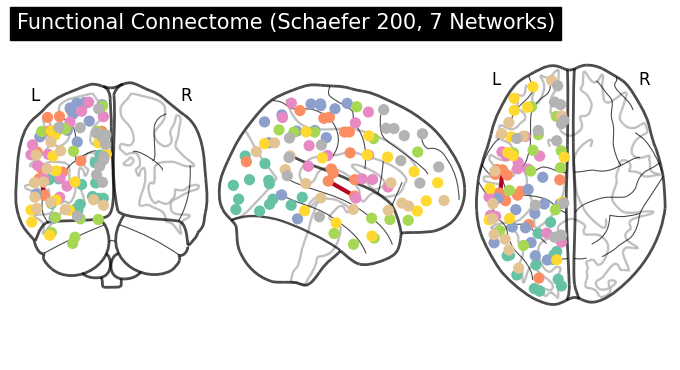

In [17]:
# Plot the connectome
plotting.plot_connectome(
    mean_matrix_adhd_female[:100, :100],
    atlas_coords[:100],
    edge_threshold=0.2,
    node_size=50,
    edge_cmap="coolwarm",
    title="Functional Connectome (Schaefer 200, 7 Networks)"
)

plotting.show()

Plotting connections based on a threshold

In [ ]:
def get_valid_nodes_based_on_threshold(input_matrix, threshold):

    # Find out the valid nodes, reduce the adjacency matrix and get the coordinates
    output_matrix = input_matrix.copy()

    output_matrix[output_matrix < threshold] = 0  # Mask values below the threshold

    # Find the indices of the nodes that have any connection greater than the threshold
    valid_nodes = np.any(output_matrix > 0, axis=0)

    # Mask the atlas coordinates and the connectivity matrix
    masked_coords = np.array(atlas_coords)[valid_nodes]
    masked_matrix = input_matrix[valid_nodes][:, valid_nodes]

    return masked_matrix, masked_coords

In [ ]:
adhd_female_significant_connections, adhd_female_coords = get_valid_nodes_based_on_threshold(mean_matrix_adhd_female, 0.15)

In [ ]:
adhd_male_significant_connections, adhd_male_coords = get_valid_nodes_based_on_threshold(mean_matrix_adhd_male, 0.15)

In [ ]:
no_adhd_female_significant_connections, no_adhd_female_coords = get_valid_nodes_based_on_threshold(mean_matrix_no_adhd_female, 0.15)

In [ ]:
no_adhd_male_significant_connections, no_adhd_male_coords = get_valid_nodes_based_on_threshold(mean_matrix_no_adhd_male, 0.15)

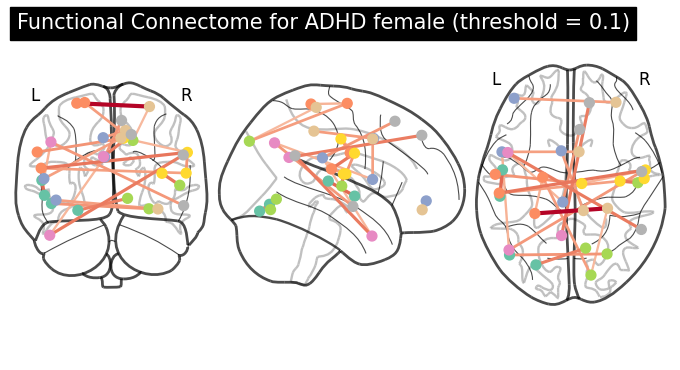

In [ ]:
plotting.plot_connectome(
    adhd_female_significant_connections,
    adhd_female_coords,
    edge_threshold=0.1,
    node_size=50,
    edge_cmap="coolwarm",
    title="Functional Connectome for ADHD female (threshold = 0.15)"
)

# Show the plot
plotting.show()

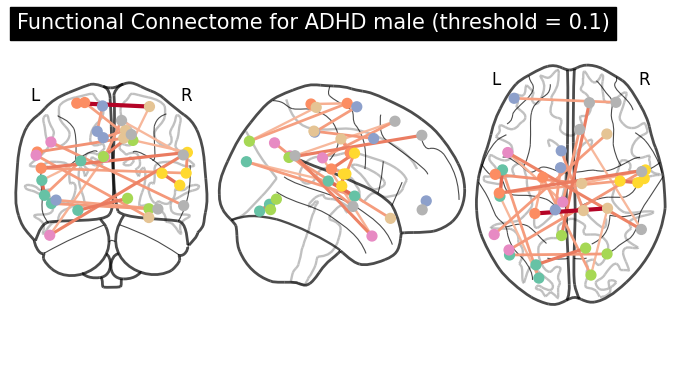

In [ ]:
plotting.plot_connectome(
    adhd_male_significant_connections,
    adhd_male_coords,
    edge_threshold=0.1,
    node_size=50,
    edge_cmap="coolwarm",
    title="Functional Connectome for ADHD male (threshold = 0.15)"
)

# Show the plot
plotting.show()

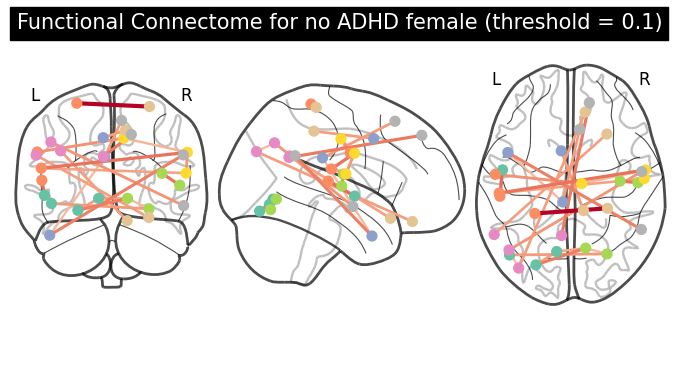

In [ ]:
plotting.plot_connectome(
    no_adhd_female_significant_connections,
    no_adhd_female_coords,
    edge_threshold=0.1,
    node_size=50,
    edge_cmap="coolwarm",
    title="Functional Connectome for no ADHD female (threshold = 0.15)"
)

# Show the plot
plotting.show()

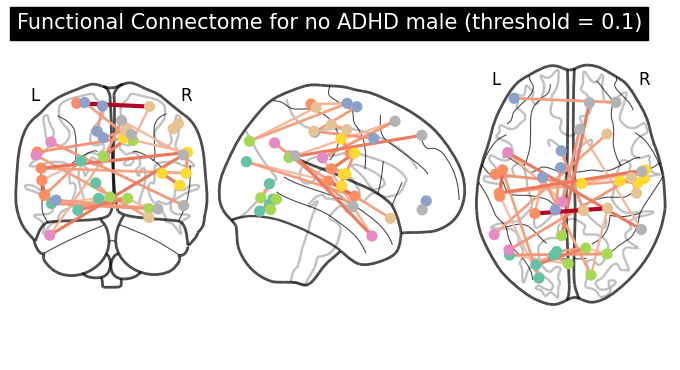

In [ ]:
plotting.plot_connectome(
    no_adhd_male_significant_connections,
    no_adhd_male_coords,
    edge_threshold=0.1,
    node_size=50,
    edge_cmap="coolwarm",
    title="Functional Connectome for no ADHD male (threshold = 0.15)"
)

# Show the plot
plotting.show()

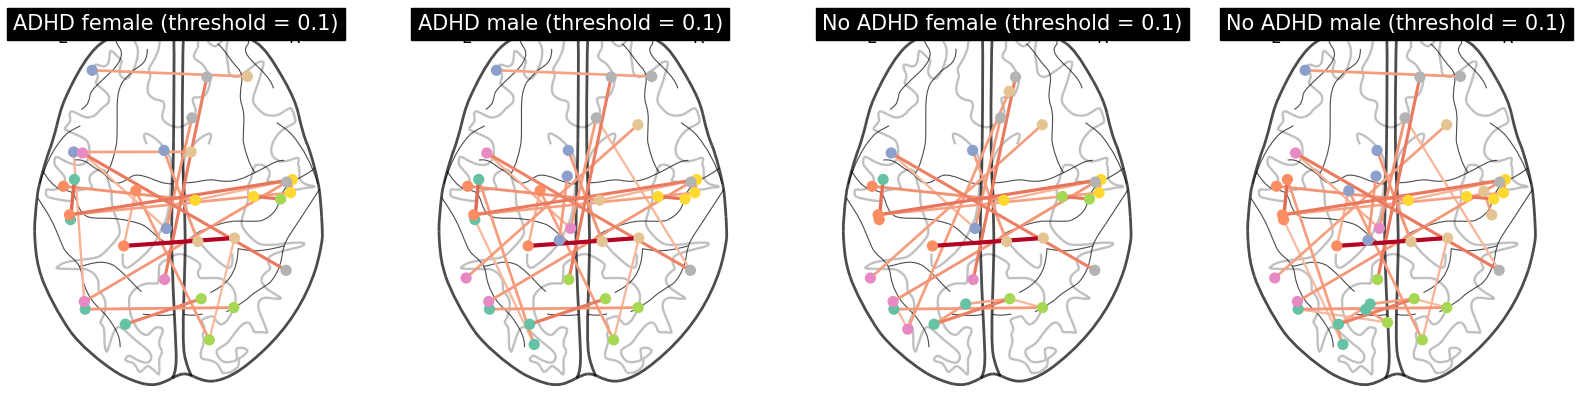

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))  # 1 row, 4 columns

plotting.plot_connectome(
    adhd_female_significant_connections,
    adhd_female_coords,
    edge_threshold=0.1,
    node_size=50,
    edge_cmap="coolwarm",
    title="ADHD female (threshold = 0.15)",
    axes=axes[0],
    display_mode="z"
)

plotting.plot_connectome(
    adhd_male_significant_connections,
    adhd_male_coords,
    edge_threshold=0.1,
    node_size=50,
    edge_cmap="coolwarm",
    title="ADHD male (threshold = 0.15)",
    axes=axes[1],
    display_mode="z"
)

plotting.plot_connectome(
    no_adhd_female_significant_connections,
    no_adhd_female_coords,
    edge_threshold=0.1,
    node_size=50,
    edge_cmap="coolwarm",
    title="No ADHD female (threshold = 0.15)",
    axes=axes[2],
    display_mode="z"
)

plotting.plot_connectome(
    no_adhd_male_significant_connections,
    no_adhd_male_coords,
    edge_threshold=0.1,
    node_size=50,
    edge_cmap="coolwarm",
    title="No ADHD male (threshold = 0.15)",
    axes=axes[3],
    display_mode="z"
)

plt.show()

These connections look a lot similar - so will do some tuple matching to see exactly what is unique about the plots.

In [66]:
def extract_high_correlation_connections(adjacency_matrix, threshold):
    # Ensure the matrix is square
    assert adjacency_matrix.shape[0] == adjacency_matrix.shape[1], "Matrix must be square!"

    # Create a boolean mask for upper triangle (excluding diagonal)
    upper_triangle_mask = np.triu(np.ones(adjacency_matrix.shape, dtype=bool), k=1)

    # Get indices where correlation is above threshold (only upper triangle)
    i, j = np.where((adjacency_matrix > threshold) & upper_triangle_mask)

    # Convert indices to list of tuples
    high_corr_nodes = list(zip(i, j))
    
    return high_corr_nodes

In [67]:
threshold = 0.15

In [68]:
adhd_female_connections = extract_high_correlation_connections(mean_matrix_adhd_female, threshold)
adhd_male_connections = extract_high_correlation_connections(mean_matrix_adhd_male, threshold)
no_adhd_female_connections = extract_high_correlation_connections(mean_matrix_no_adhd_female, threshold)
no_adhd_male_connections = extract_high_correlation_connections(mean_matrix_no_adhd_male, threshold)

In [69]:
def find_unique_connections(connection_1, connection_2):
    set_1 = set(map(tuple, connection_1))
    set_2 = set(map(tuple, connection_2))
    
    # Find differences (tuples not common in both sets)
    unique_tuples = set_1.symmetric_difference(set_2)
    
    # Convert back to numpy array
    return np.array(list(unique_tuples))

In [109]:
def find_unique_connections_for_each_connections(connection_1, connection_2):
    unique_connections_1 = [connection for connection in connection_1 if connection not in connection_2]

    unique_connections_2 = [connection for connection in connection_2 if connection not in connection_1]

    return unique_connections_1, unique_connections_2

In [78]:
def find_number_of_connections(connections):
    left_conn = 0
    right_conn = 0
    inter_conn = 0

    for connection in connections:
        if (connection[0] < 101 and connection[1] < 101):
            left_conn += 1
        elif (connection[0] > 100 and connection[1] > 100):
            right_conn += 1
        else:
            inter_conn += 1

    return left_conn, right_conn, inter_conn

Calculate the number of left, right and inter connections to figure out if they are significant.

In [80]:
adhd_female_left_conn, adhd_female_right_conn, adhd_female_inter_conn = find_number_of_connections(adhd_female_connections)
adhd_male_left_conn, adhd_male_right_conn, adhd_male_inter_conn = find_number_of_connections(adhd_male_connections)
no_adhd_female_left_conn, no_adhd_female_right_conn, no_adhd_female_inter_conn = find_number_of_connections(no_adhd_female_connections)
no_adhd_male_left_conn, no_adhd_male_right_conn, no_adhd_male_inter_conn = find_number_of_connections(no_adhd_male_connections)

In [81]:
print("The connection count for each of the types")
print(f"For adhd females - left {adhd_female_left_conn}, right {adhd_female_right_conn}, inter-connections {adhd_female_inter_conn}")
print(f"For adhd males - left {adhd_male_left_conn}, right {adhd_male_right_conn}, inter-connections {adhd_male_inter_conn}")
print(f"For no adhd females - left {no_adhd_female_left_conn}, right {no_adhd_female_right_conn}, inter-connections {no_adhd_female_inter_conn}")
print(f"For no adhd males - left {no_adhd_male_left_conn}, right {no_adhd_male_right_conn}, inter-connections {no_adhd_male_inter_conn}")

The connection count for each of the types
For adhd females - left 1, right 2, inter-connections 13
For adhd males - left 3, right 2, inter-connections 14
For no adhd females - left 2, right 2, inter-connections 12
For no adhd males - left 3, right 3, inter-connections 16


Getting the differences among two classes to figure out exactly what connections can be attributed to which feature

In [139]:
unique_connections_adhd_female_sex_comparison, unique_connections_adhd_male_sex_comparison = find_unique_connections_for_each_connections(adhd_female_connections, adhd_male_connections)
unique_connections_no_adhd_female_sex_comparison, unique_connections_no_adhd_male_sex_comparison = find_unique_connections_for_each_connections(no_adhd_female_connections, no_adhd_male_connections)
unique_connections_adhd_female_adhd_comparison, unique_connections_no_adhd_female_adhd_comparison = find_unique_connections_for_each_connections(adhd_female_connections, no_adhd_female_connections)
unique_connections_adhd_male_adhd_comparison, unique_connections_no_adhd_male_adhd_comparison = find_unique_connections_for_each_connections(adhd_male_connections, no_adhd_male_connections)

In [140]:
print(f"ADHD female unique connections compared to ADHD male:")
for tuple in unique_connections_adhd_female_sex_comparison:
    print(tuple)

print(f"\nADHD male unique connections compared to ADHD female:")
for tuple in unique_connections_adhd_male_sex_comparison:
    print(tuple)

ADHD female unique connections compared to ADHD male:
(np.int64(49), np.int64(155))

ADHD male unique connections compared to ADHD female:
(np.int64(13), np.int64(14))
(np.int64(18), np.int64(120))
(np.int64(52), np.int64(53))
(np.int64(80), np.int64(159))


In [141]:
print(f"No ADHD female unique connections compared to no ADHD male:")
for tuple in unique_connections_no_adhd_female_sex_comparison:
    print(tuple)

print(f"\nNo ADHD male unique connections compared to no ADHD female:")
for tuple in unique_connections_no_adhd_male_sex_comparison:
    print(tuple)

No ADHD female unique connections compared to no ADHD male:
(np.int64(1), np.int64(3))
(np.int64(79), np.int64(158))

No ADHD male unique connections compared to no ADHD female:
(np.int64(3), np.int64(103))
(np.int64(9), np.int64(108))
(np.int64(13), np.int64(14))
(np.int64(18), np.int64(120))
(np.int64(27), np.int64(113))
(np.int64(52), np.int64(53))
(np.int64(65), np.int64(169))
(np.int64(123), np.int64(124))


In [142]:
print(f"ADHD female unique connections compared to no ADHD female:")
for tuple in unique_connections_adhd_female_adhd_comparison:
    print(tuple)

print(f"\nNo ADHD female unique connections compared to ADHD female:")
for tuple in unique_connections_no_adhd_female_adhd_comparison:
    print(tuple)

ADHD female unique connections compared to no ADHD female:
(np.int64(27), np.int64(113))
(np.int64(49), np.int64(155))
(np.int64(65), np.int64(169))

No ADHD female unique connections compared to ADHD female:
(np.int64(1), np.int64(3))
(np.int64(79), np.int64(158))
(np.int64(80), np.int64(159))


In [143]:
print(f"ADHD male unique connections compared to no ADHD male:")
for tuple in unique_connections_adhd_male_adhd_comparison:
    print(tuple)

print(f"\nNo ADHD male unique connections compared to ADHD male:")
for tuple in unique_connections_no_adhd_male_adhd_comparison:
    print(tuple)

ADHD male unique connections compared to no ADHD male:

No ADHD male unique connections compared to ADHD male:
(np.int64(3), np.int64(103))
(np.int64(9), np.int64(108))
(np.int64(123), np.int64(124))


In [144]:
female_connections = list(set(adhd_female_connections).union(no_adhd_female_connections))

In [119]:
male_connections = list(set(adhd_male_connections).union(no_adhd_male_connections))

In [120]:
adhd_connections = list(set(adhd_female_connections).union(adhd_male_connections))

In [121]:
no_adhd_connections = list(set(no_adhd_female_connections).union(no_adhd_male_connections))